# expeirments.ipynb

# Assignment 4
### CSC 537: Deep Learning

**Author:** Xander Palermo — ajp2s@missouristate.edu <br>
**Professor:** Mukulika Ghosh <br>
**Date:** 27 April 2026

----

## Imports

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pickle
import torch.cuda

import ShakespeareDataset

In [29]:
from RNN import *

Imported helper functions (from prev. assignments)

In [30]:
plot_path = "./results/"


def save_plot(exp_plot, exp_num, exp_name, suffix="") -> None:
    """
    Saves a plot to designated location
    :param exp_plot: the experiment's plot
    :param exp_num: the experiment's number
    :param exp_name: the experiment's name
    :param suffix: (optional) a title suffix to differentiate plots from the same experiment
    :return: None
    """
    file_type = ".png"
    complete_path = plot_path + f"exp_{exp_num}/{exp_name}" + suffix + file_type
    exp_plot.savefig(complete_path)
    print(f'\t\t saved to {complete_path}')


def gen_plot(df: pd.DataFrame,
             independent_var: str,
             experiment_number: int, experiment_title: str,
             dependent_var: str = "Loss",
             subtitle: str = None
             ) -> sns.FacetGrid:
    """
    generates a grid of plots for the experiment
    :param df: DataFrame containing data to be plotted. Data Frame should have a column containing Iterations, and 2 columns mapping Independent Variable -> Dependent Variable
    :param independent_var: the variable that is being changed for each execution of the gradient descent algorithm
    :param experiment_number: The experiment number
    :param experiment_title: The experiment title
    :param dependent_var: (DEFAULT: LOSS) the value to be tracked over iterations
    :param subtitle: (DEFAULT: none included) a descriptor of what the graph displays
    :return:
    """
    g = sns.relplot(
        data=df,
        kind='line', x='Epoch', y=dependent_var,
        hue=independent_var, legend=True
    )
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f"Experiment {experiment_number}: {experiment_title}")
    if subtitle is not None:
        g.fig.text(0.5, 0.91, subtitle, ha='center', fontsize=10, color='gray')
    return g


def save_table(df: pd.DataFrame, exp_num, exp_name, suffix="") -> None:
    """
    Saves a dataframe as a table to designated location.

    Saves as Microsoft Excel spreadsheet
    :param df: the experiment's plot
    :param exp_num: the experiment's number
    :param exp_name: the experiment's name
    :param suffix: (optional) a title suffix to differentiate plots from the same experiment
    :return: None
    """
    file_type = ".xlsx"
    complete_path = plot_path + f"exp_{exp_num}/{exp_name}" + suffix + file_type
    df.to_excel(complete_path)
    print(f'\t\t saved to {complete_path}')

In [31]:
def calculate_perplexity(loss_over_epoch):
    avg_loss = np.mean(loss_over_epoch)
    return math.exp(avg_loss)

## Start Up

Unpickle compiled DataLoader Objects

In [32]:
path = "dataset/"

with open(f'{path}training_norm_shakespeare.pkl', 'rb') as f:
    training_data = pickle.load(f)

with open(f'{path}training_short_shakespeare.pkl', 'rb') as f:
    training_data_short = pickle.load(f)

with open(f'{path}validation_shakespeare.pkl', 'rb') as f:
    validation_data = pickle.load(f)

with open(f'{path}validation_short_shakespeare.pkl', 'rb') as f:
    validation_data_short = pickle.load(f)

with open(f'{path}testing_shakespeare.pkl', 'rb') as f:
    testing_data = pickle.load(f)

with open(f'{path}testing_short_shakespeare.pkl', 'rb') as f:
    testing_data_short = pickle.load(f)

Initialize GPU (if available)

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device == torch.device('cuda'):
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 2060


Configure Seaborn Plot

In [34]:
sns.set_style("whitegrid")
sns.set_palette("bright")

Initialize Constants

In [35]:
LR = 1e-6

----


## Experiment A

In [36]:
experiment_title        = "Architecture Comparison"
experiment_number       = 1
independent_variable    = "Architecture"

**Independent Variables**

In [37]:
simple_rnn = RNN(len(char2idx), 64, len(idx2char), isLSTM=False)
lstm = RNN(len(char2idx), 64, len(idx2char), isLSTM=True)

### Experiement

Initialize lists to capture data

In [38]:
simple_rnn_training_loss, simple_rnn_validation_loss,  = [], []
lstm_training_loss, lstm_validation_loss,  = [], []

Perform training and validation on models

In [39]:
%%time
print("Starting Training on simple rnn...")
simple_rnn = train(simple_rnn, training_data, validation_data,
                   training_tracker=simple_rnn_training_loss, validation_tracker=simple_rnn_validation_loss,
                   THRESH=LR, verbose=True, device=device)
print("Training on simple rnn complete.")

torch.cuda.synchronize()

Starting Training on simple rnn...
		Epoch 1/100
			training avg_loss=1.9016
			validation avg_loss=1.7454
		Epoch 11/100
			training avg_loss=1.6755
			validation avg_loss=1.6748
		Epoch 21/100
			training avg_loss=1.6694
			validation avg_loss=1.6692
		Epoch 31/100
			training avg_loss=1.6671
			validation avg_loss=1.6665
		Epoch 41/100
			training avg_loss=1.6661
			validation avg_loss=1.6664
		Epoch 51/100
			training avg_loss=1.6656
			validation avg_loss=1.6652
		Epoch 61/100
			training avg_loss=1.6651
			validation avg_loss=1.6655
		Epoch 71/100
			training avg_loss=1.6645
			validation avg_loss=1.6645
		Epoch 81/100
			training avg_loss=1.6643
			validation avg_loss=1.6637
		Epoch 91/100
			training avg_loss=1.6640
			validation avg_loss=1.6634
Training on simple rnn complete.
CPU times: total: 1h 2min 47s
Wall time: 57min 52s


In [40]:
%%time
print("Starting Training on simple rnn...")
lstm = train(lstm, training_data, validation_data,
             training_tracker=lstm_training_loss, validation_tracker=lstm_validation_loss,
             THRESH=LR, verbose=True, device=device)
print("Training on simple rnn complete.")

torch.cuda.synchronize()

Starting Training on simple rnn...
		Epoch 1/100
			training avg_loss=1.9342
			validation avg_loss=1.6885
		Epoch 11/100
			training avg_loss=1.4972
			validation avg_loss=1.4954
		Epoch 21/100
			training avg_loss=1.4799
			validation avg_loss=1.4791
		Epoch 31/100
			training avg_loss=1.4731
			validation avg_loss=1.4723
		Epoch 41/100
			training avg_loss=1.4692
			validation avg_loss=1.4684
		Epoch 51/100
			training avg_loss=1.4669
			validation avg_loss=1.4669
		Epoch 61/100
			training avg_loss=1.4652
			validation avg_loss=1.4654
		Epoch 71/100
			training avg_loss=1.4639
			validation avg_loss=1.4637
		Epoch 81/100
			training avg_loss=1.4629
			validation avg_loss=1.4628
		Epoch 91/100
			training avg_loss=1.4620
			validation avg_loss=1.4618
Training on simple rnn complete.
CPU times: total: 1h 10min 18s
Wall time: 1h 5min 39s


Perform final evaluation on model performance

In [41]:
%%time
print("Starting Testing on simple rnn...")
simple_rnn_avg_loss = evaluate(simple_rnn, testing_data, device=device)
print("Testing on simple rnn complete.")

torch.cuda.synchronize()

Starting Testing on simple rnn...
Testing on simple rnn complete.
CPU times: total: 15.2 s
Wall time: 13.5 s


In [42]:
%%time
print("Starting Testing on simple rnn...")
lstm_avg_loss = evaluate(lstm, testing_data, device=device)
print("Testing on simple rnn complete.")

torch.cuda.synchronize()

Starting Testing on simple rnn...
Testing on simple rnn complete.
CPU times: total: 16.8 s
Wall time: 15.2 s


### Plotting

Construct DataFrame objects to compare model performance

In [43]:
pd.__version__

'3.0.2'

In [44]:
max_len = max(len(simple_rnn_training_loss), len(lstm_training_loss))

training_loss = pd.DataFrame({
    "Simple RNN": simple_rnn_training_loss + [np.nan] * (max_len - len(simple_rnn_training_loss)),
    "LSTM":       lstm_training_loss       + [np.nan] * (max_len - len(lstm_training_loss)),
})

validation_loss = pd.DataFrame({
    "Simple RNN"    : simple_rnn_validation_loss + [np.nan] * (max_len - len(simple_rnn_validation_loss)),
    "LSTM"          : lstm_validation_loss + [np.nan] * (max_len - len(lstm_validation_loss)),
})

plot_data_loss = {
    "Training Loss"     : training_loss,
    "Validation Loss"   : validation_loss,
}

results = pd.DataFrame({
    independent_variable    : ["Simple RNN", "LSTM"],
    "Test Loss"             : [simple_rnn_avg_loss, lstm_avg_loss],
    "Perplexity"            : [calculate_perplexity(simple_rnn_validation_loss), calculate_perplexity(lstm_validation_loss)],
})

Prepare DataFrame and plot results generated by the loss function

In [45]:
plots = dict()

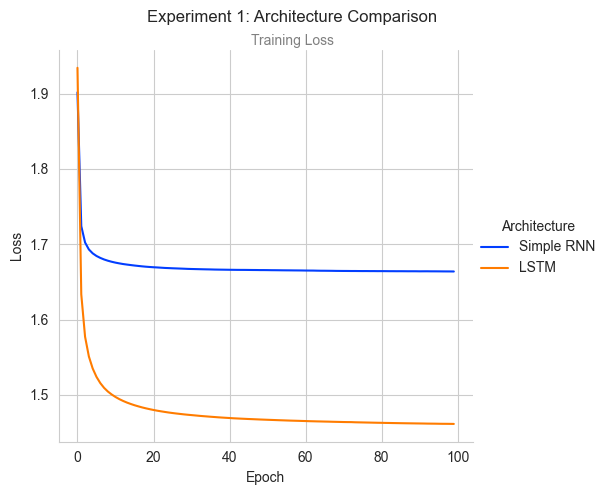

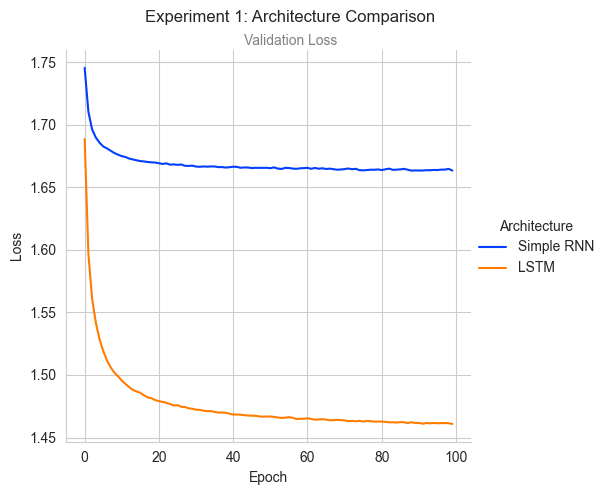

In [46]:
for identifier, df in plot_data_loss.items():
    df["Epoch"] = df.index
    df = pd.melt(df, id_vars=["Epoch"], var_name=independent_variable, value_name="Loss")
    plots[identifier] = gen_plot(df, independent_variable, experiment_number, experiment_title, subtitle=identifier)
    plt.show()

Construct table of final test results

In [47]:
results.set_index(independent_variable, inplace=True)
display(results)

,Test Loss,Perplexity
Architecture,,
Simple RNN,1.663328,5.304773
LSTM,1.460909,4.376865


Save all figures to disk

In [48]:
for identifier, g in plots.items():
    save_plot(g, experiment_number, experiment_title, suffix=f" - {identifier}")

save_table(results, experiment_number, experiment_title, suffix=f" - Results")

		 saved to ./results/exp_1/Architecture Comparison - Training Loss.png
		 saved to ./results/exp_1/Architecture Comparison - Validation Loss.png
		 saved to ./results/exp_1/Architecture Comparison - Results.xlsx


## Experiment B

In [49]:
experiment_title        = "Sequence Length"
experiment_number       = 2
independent_variable    = "Sequence Length Comparison"

**Independent Variables**

In [50]:
# Control Variable
#   training_data
# Short Sequence
#   training_data_short

In [51]:
short_model = RNN(len(char2idx), 64, len(idx2char), isLSTM=True)
long_model  = RNN(len(char2idx), 64, len(idx2char), isLSTM=True)

### Experiment

Initialize lists to capture data

In [52]:
short_training_loss, short_validation_loss = [], []
long_training_loss, long_validation_loss = [], []

Perform training and validation on models

In [53]:
%%time
print("Starting Training on short model...")
short_model = train(short_model, training_data_short, validation_data_short,
                    training_tracker=short_training_loss, validation_tracker=short_validation_loss,
                    THRESH=LR, verbose=True, device=device)
print("Training on short model complete.")

torch.cuda.synchronize()

Starting Training on short model...
		Epoch 1/100
			training avg_loss=1.9853
			validation avg_loss=1.7488
		Epoch 11/100
			training avg_loss=1.5586
			validation avg_loss=1.5572
		Epoch 21/100
			training avg_loss=1.5400
			validation avg_loss=1.5393
		Epoch 31/100
			training avg_loss=1.5324
			validation avg_loss=1.5318
		Epoch 41/100
			training avg_loss=1.5281
			validation avg_loss=1.5276
		Epoch 51/100
			training avg_loss=1.5253
			validation avg_loss=1.5246
Training on short model complete.
CPU times: total: 33min 41s
Wall time: 31min 10s


In [54]:
%%time
print("Starting Training on long model...")
long_model = train(long_model, training_data, validation_data,
                   training_tracker=long_training_loss, validation_tracker=long_validation_loss,
                   THRESH=LR, verbose=True, device=device)
print("Training on long model complete.")

torch.cuda.synchronize()

Starting Training on long model...
		Epoch 1/100
			training avg_loss=1.9110
			validation avg_loss=1.6684
		Epoch 11/100
			training avg_loss=1.4974
			validation avg_loss=1.4960
		Epoch 21/100
			training avg_loss=1.4809
			validation avg_loss=1.4798
		Epoch 31/100
			training avg_loss=1.4744
			validation avg_loss=1.4741
		Epoch 41/100
			training avg_loss=1.4704
			validation avg_loss=1.4700
		Epoch 51/100
			training avg_loss=1.4679
			validation avg_loss=1.4672
		Epoch 61/100
			training avg_loss=1.4658
			validation avg_loss=1.4655
		Epoch 71/100
			training avg_loss=1.4642
			validation avg_loss=1.4637
		Epoch 81/100
			training avg_loss=1.4631
			validation avg_loss=1.4629
		Epoch 91/100
			training avg_loss=1.4622
			validation avg_loss=1.4614
Training on long model complete.
CPU times: total: 1h 11min 12s
Wall time: 1h 6min 35s


Perform final evaluation on model performance

In [55]:
%%time
print("Starting Testing on short model...")
short_avg_loss = evaluate(short_model, testing_data_short, device=device)
print("Testing on short model complete.")

torch.cuda.synchronize()

Starting Testing on short model...
Testing on short model complete.
CPU times: total: 15.7 s
Wall time: 14.2 s


In [56]:
%%time
print("Starting Testing on long model...")
long_avg_loss = evaluate(long_model, testing_data, device=device)
print("Testing on long model complete.")

torch.cuda.synchronize()

Starting Testing on long model...
Testing on long model complete.
CPU times: total: 16.6 s
Wall time: 15.3 s


### Plotting

Construct DataFrame objects to compare model performance

In [57]:
max_len = max(len(short_training_loss), len(long_training_loss))

training_loss = pd.DataFrame({
    "Short Length Sequence"     : short_training_loss + [np.nan] * (max_len - len(short_training_loss)),
    "Long Length Sequence"      : long_training_loss + [np.nan] * (max_len - len(long_training_loss)),
})

validation_loss = pd.DataFrame({
    "Short Length Sequence"     : short_validation_loss + [np.nan] * (max_len - len(short_validation_loss)),
    "Long Length Sequence"      : long_validation_loss + [np.nan] * (max_len - len(long_validation_loss)),
})

plot_data_loss = {
    "Training Loss"   : training_loss,
    "Validation Loss" : validation_loss,
}

results = pd.DataFrame({
    independent_variable        : ["Short Length Sequence", "Long Length Sequence"],
    "Test Loss"                 : [short_avg_loss, long_avg_loss],
    "Perplexity"                : [calculate_perplexity(short_validation_loss), calculate_perplexity(long_validation_loss)],
})

Prepare DataFrame and plot results generated by the loss function

In [58]:
plots = {}

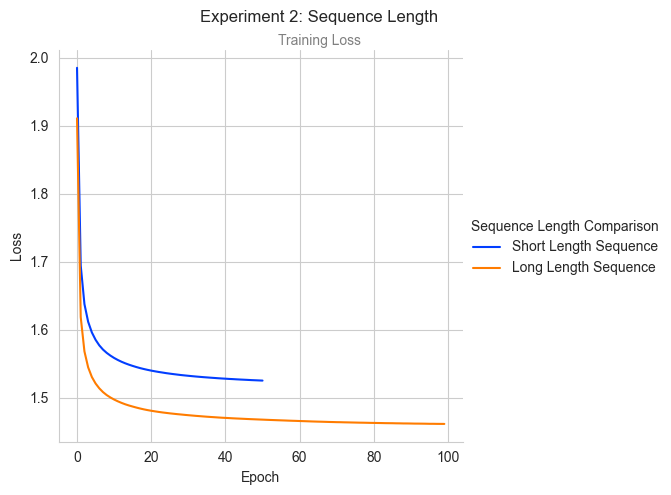

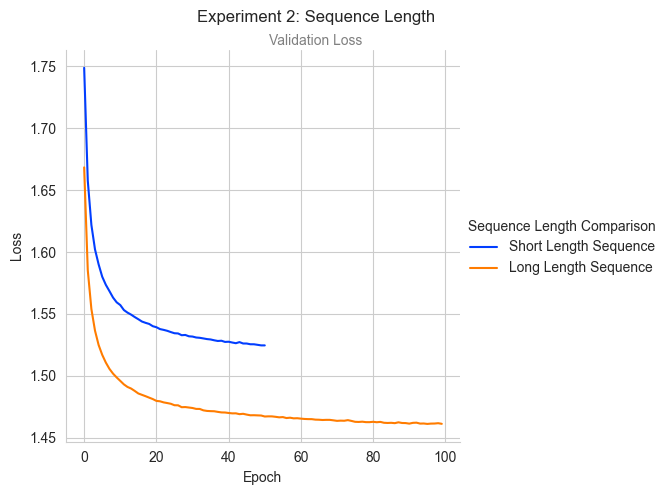

In [59]:
for identifier, df in plot_data_loss.items():
    df["Epoch"] = df.index
    df = pd.melt(df, id_vars=["Epoch"], var_name=independent_variable, value_name="Loss")
    plots[identifier] = gen_plot(df, independent_variable, experiment_number, experiment_title, subtitle=identifier)
    plt.show()

Construct table of final test results

In [60]:
results.set_index(independent_variable, inplace=True)
display(results)

,Test Loss,Perplexity
Sequence Length Comparison,,
Short Length Sequence,1.524630,4.704346
Long Length Sequence,1.461278,4.377264


Save all figures to disk

In [61]:
for identifier, g in plots.items():
    save_plot(g, experiment_number, experiment_title, suffix=f" - {identifier}")

save_table(results, experiment_number, experiment_title, suffix=f" - Results")

		 saved to ./results/exp_2/Sequence Length - Training Loss.png
		 saved to ./results/exp_2/Sequence Length - Validation Loss.png
		 saved to ./results/exp_2/Sequence Length - Results.xlsx


## Experiments C

In [62]:
experiment_title        = "Hidden Size Comparison"
experiment_number       = 3
independent_variable    = "Hidden Size"

**Independent Variables**

In [63]:
small_rnn = RNN(len(char2idx), 32, len(idx2char), isLSTM=True)
large_rnn = RNN(len(char2idx), 64, len(idx2char), isLSTM=True)

### Experiment

Initialize lists to capture data

In [64]:
small_training_loss, small_validation_loss = [], []
large_training_loss, large_validation_loss = [], []

In [65]:
%%time
print("Starting Training on small model...")
small_rnn = train(small_rnn, training_data, validation_data,
                  training_tracker=small_training_loss, validation_tracker=small_validation_loss,
                  THRESH=LR, verbose=True, device=device)
print("Training on small model complete.")

torch.cuda.synchronize()

Starting Training on small model...
		Epoch 1/100
			training avg_loss=2.1278
			validation avg_loss=1.8926
		Epoch 11/100
			training avg_loss=1.7214
			validation avg_loss=1.7199
		Epoch 21/100
			training avg_loss=1.7075
			validation avg_loss=1.7071
		Epoch 31/100
			training avg_loss=1.7023
			validation avg_loss=1.7020
		Epoch 41/100
			training avg_loss=1.6988
			validation avg_loss=1.6988
		Epoch 51/100
			training avg_loss=1.6965
			validation avg_loss=1.6963
		Epoch 61/100
			training avg_loss=1.6948
			validation avg_loss=1.6949
		Epoch 71/100
			training avg_loss=1.6937
			validation avg_loss=1.6938
		Epoch 81/100
			training avg_loss=1.6929
			validation avg_loss=1.6926
		Epoch 91/100
			training avg_loss=1.6921
			validation avg_loss=1.6920
Training on small model complete.
CPU times: total: 1h 6min 32s
Wall time: 1h 1min 32s


In [66]:
%%time
print("Starting Training on large model...")
large_rnn = train(large_rnn, training_data, validation_data,
                  training_tracker=large_training_loss, validation_tracker=large_validation_loss,
                  THRESH=LR, verbose=True, device=device)
print("Training on large model complete.")

torch.cuda.synchronize()

Starting Training on large model...
		Epoch 1/100
			training avg_loss=1.9392
			validation avg_loss=1.6922
		Epoch 11/100
			training avg_loss=1.5074
			validation avg_loss=1.5057
		Epoch 21/100
			training avg_loss=1.4908
			validation avg_loss=1.4900
		Epoch 31/100
			training avg_loss=1.4839
			validation avg_loss=1.4840
		Epoch 41/100
			training avg_loss=1.4800
			validation avg_loss=1.4797
		Epoch 51/100
			training avg_loss=1.4776
			validation avg_loss=1.4780
		Epoch 61/100
			training avg_loss=1.4759
			validation avg_loss=1.4756
Training on large model complete.
CPU times: total: 43min 58s
Wall time: 41min 4s


Perform final evaluation on model performance

In [67]:
%%time
print("Starting Testing on small model...")
small_avg_loss = evaluate(small_rnn, testing_data, device=device)
print("Testing on small model complete.")

torch.cuda.synchronize()

Starting Testing on small model...
Testing on small model complete.
CPU times: total: 15.9 s
Wall time: 14.8 s


In [68]:
%%time
print("Starting Testing on large model...")
large_avg_loss = evaluate(large_rnn, testing_data, device=device)
print("Testing on large model complete.")

torch.cuda.synchronize()

Starting Testing on large model...
Testing on large model complete.
CPU times: total: 17.5 s
Wall time: 16 s


### Plotting

Construct DataFrame objects to compare model performance

In [69]:
max_len = max(len(small_training_loss), len(large_training_loss))

training_loss = pd.DataFrame({
    "Small RNN" : small_training_loss + [np.nan] * (max_len - len(small_training_loss)),
    "Large RNN" : large_training_loss + [np.nan] * (max_len - len(large_training_loss)),
})

validation_loss = pd.DataFrame({
    "Small RNN" : small_validation_loss + [np.nan] * (max_len - len(small_validation_loss)),
    "Large RNN" : large_validation_loss + [np.nan] * (max_len - len(large_validation_loss)),
})

plot_data_loss = {
    "Training Loss"     : training_loss,
    "Validation Loss"   : validation_loss,
}

results = pd.DataFrame({
    independent_variable    : ["Small RNN", "Large RNN"],
    "Test Loss"             : [small_avg_loss, large_avg_loss],
    "Perplexity"            : [calculate_perplexity(small_validation_loss), calculate_perplexity(large_validation_loss)],
})

Prepare DataFrame and plot results generated by the loss function

In [70]:
plots = dict()

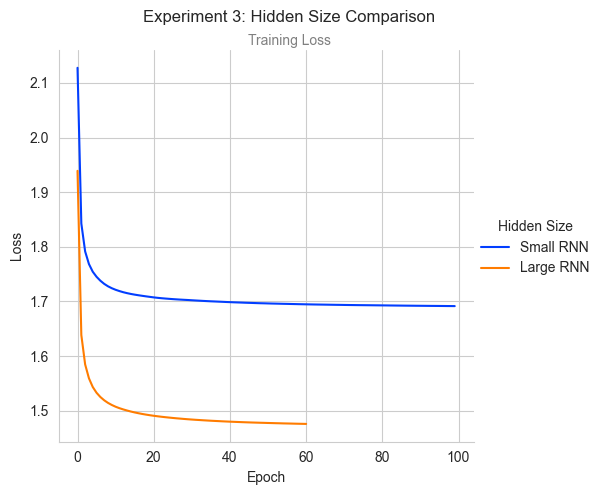

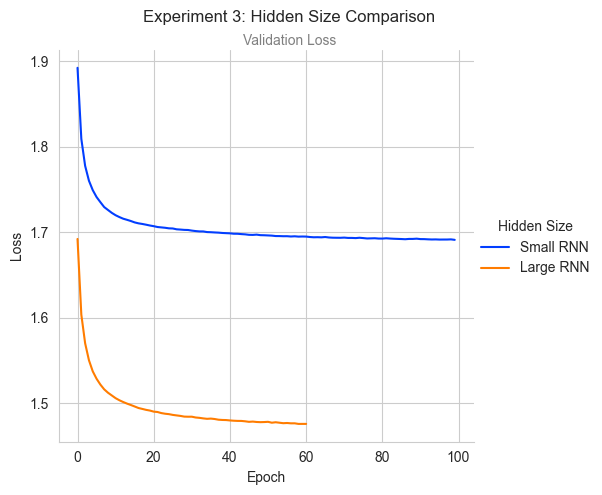

In [71]:
for identifier, df in plot_data_loss.items():
    df["Epoch"] = df.index
    df = pd.melt(df, id_vars=["Epoch"], var_name=independent_variable, value_name="Loss")
    plots[identifier] = gen_plot(df, independent_variable, experiment_number, experiment_title, subtitle=identifier)
    plt.show()

Construct table of final test results

In [72]:
results.set_index(independent_variable, inplace=True)
display(results)

,Test Loss,Perplexity
Hidden Size,,
Small RNN,1.691117,5.499423
Large RNN,1.475614,4.461637


Save all figures to disk

In [73]:
for identifier, g in plots.items():
    save_plot(g, experiment_number, experiment_title, suffix=f" - {identifier}")

save_table(results, experiment_number, experiment_title, suffix=f" - Results")

		 saved to ./results/exp_3/Hidden Size Comparison - Training Loss.png
		 saved to ./results/exp_3/Hidden Size Comparison - Validation Loss.png
		 saved to ./results/exp_3/Hidden Size Comparison - Results.xlsx
